In [76]:
# Libreria para extraer comentarios de Youtube
!pip install youtube-comment-downloader
# Descargar modelo español de spaCy
!python -m spacy download es_core_news_sm
!python -m spacy download en_core_web_sm

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
     ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
     ---- ----------------------------------- 1.3/12.9 MB 8.4 MB/s eta 0:00:02
     ----------- ---------------------------- 3.7/12.9 MB 10.4 MB/s eta 0:00:01
     ---------------- ----------------------- 5.2/12.9 MB 9.4 MB/s eta 0:00:01
     --------------------- ------------------ 7.1/12.9 MB 9.5 MB/s eta 0:00:01
     ---------------------------- ----------- 9.2/12.9 MB 9.5 MB/s eta 0:00:01
     ---------------------------------- ----- 11.3/12.9 MB 9.8 MB/s eta 0:00:01
     ---------------------------------------- 12.9/12.9 MB 10.0 MB/s  0:00:01
✔ Download and installation successful
You can now load the package via 

## Obtenemos comentarios de un video de youtube:

In [77]:
import pandas as pd
from itertools import islice
from youtube_comment_downloader import *

downloader = YoutubeCommentDownloader()
video_url = "https://www.youtube.com/watch?v=vrONPSHn-1U" # Cambia por el link del video de interés
comments = downloader.get_comments_from_url(video_url, sort_by=SORT_BY_POPULAR)
list_comments = list(comments)

In [78]:
df = pd.DataFrame(list_comments)
df

,cid,text,time,author,channel,votes,replies,photo,heart,reply,time_parsed
0,UgzbZC3GyhV-x9tcVf54AaABAg,Classic. No 10.,hace 2 semanas,@WowW-vw9wo,UClHpfUbqBqb5ccrQj97DgMg,191,1,https://yt3.ggpht.com/ytc/AIdro_mmWqNlRovwqpf2...,False,False,1.773277e+09
1,UgxzDC0YMndSk3gumkd4AaABAg,Lo que fue james y tiago juntos en ese bayer ...,hace 12 días,@diegojimenez-c8m,UCMKuBMUoaZRaNY6wM0ijDUw,28,,https://yt3.ggpht.com/ytc/AIdro_kXlbIj8ZPnDdAy...,False,False,1.773450e+09
2,Ugx81Zn9QFM50qXZ72B4AaABAg,"Se sorprenden con LUIS DIAZ,.......YA SE LES O...",hace 11 días,@JuanPabloJiménezRios-j2x,UClXwXqhky1tI02DBw7TAX6A,19,,https://yt3.ggpht.com/ytc/AIdro_l8eo8-U6Hq182H...,False,False,1.773536e+09
3,Ugy20vZPyQNhoNKxnbx4AaABAg,Cómo no te va a gustar el frío de Munich James...,hace 2 semanas,@gabrielgranados2428,UCRBfosTXjhkofc_KKkHpsrg,314,23,https://yt3.ggpht.com/ytc/AIdro_mM_huKT3rlxAl2...,False,False,1.773277e+09
4,Ugx_yQajsHiPRtaNzix4AaABAg,初っ端から天才すぎる,hace 2 semanas,@tk-wv6yq,UCp904pEY40lYlZ9WwN3cBjg,45,,https://yt3.ggpht.com/ytc/AIdro_kH1ycPLoEVEFp2...,False,False,1.773277e+09
...,...,...,...,...,...,...,...,...,...,...,...
156,UgxQ5fFNAeQZlIbiQmh4AaABAg,"James es mañoso, calculador, trotoncito. Un pe...",hace 9 días,@joseconradocortescortes612,UCzgN3QS-cBExSSf-R0kp2QQ,0,,https://yt3.ggpht.com/ytc/AIdro_kLRchHPkvooSd3...,False,False,1.773709e+09
157,Ugzc_XVU8hp39QAJQPV4AaABAg,"Nice video, but not prime James.",hace 2 semanas (editado),@sebastiandresilva,UCMS0AB4fFt0x5w2k6AQxDzg,0,,https://yt3.ggpht.com/49G7Df6c51QgOHGPK0x1r0VT...,False,False,1.773277e+09
158,UgzZB8BsTmaRXQPbozV4AaABAg,JAJAJAJAJAJAJ SOLOVIVEN DEL RECUERDO ES UN EXJ...,hace 13 días,@johnARENAS-q2e,UCudozEtOblUTf74LUE_6vFA,0,,https://yt3.ggpht.com/ytc/AIdro_ldr9MvPwL_XnqB...,False,False,1.773364e+09
159,UgyzbWMZ704ooTAHnOZ4AaABAg,ídolo total James,hace 2 semanas,@jadadelpolaco,UCxKR4KYBUVaJ6Xz3MjJi8XQ,7,,https://yt3.ggpht.com/ytc/AIdro_khSbcYOk-ZJpJd...,False,False,1.773277e+09


In [79]:
count = 10
for _, comment in df.iterrows():
    if count == 0:
        break
    count -= 1
    print(comment['text'])
    print('--------')


Classic. No 10.
--------
Lo que fue james y tiago juntos en ese bayer   una locura
--------
Se sorprenden con LUIS DIAZ,.......YA SE LES OLVIDARON TODAS ESTÁS ACTUACIONES DE OTRO GRAN COLOMBIANO:  J A M E Z  R O D R I G U E Z .!!!!!!!!!!!
--------
Cómo no te va a gustar el frío de Munich James caremonda, hubieras tenido una carrera aún mejor
--------
初っ端から天才すぎる
--------
Calidad en su máxima expresión… así de siemple.
--------
James Rodriguez Is All About World Class
--------
Imagine Kane & James
--------
James en el Bayern está infravalorado, ahí encontró su lugar...
--------
James was a pure genius!
--------


In [80]:
import nltk
import spacy
import re
nltk.download('stopwords')
from nltk.corpus import stopwords

# nlp para comentarios en español
nlp = spacy.load("es_core_news_sm")
# nlp para comentarios en ingles
nlp_en = spacy.load("en_core_web_sm")

# Preprocesar
# StopWords en español
stopwords_es = set(stopwords.words('spanish'))
stopwords_adicionales = set(['james','bayern'])
stopwords_es.update(stopwords_adicionales)
# StopWords en ingles
stopwords_en = set(stopwords.words('english'))

def preprocess(text):
    # Convertir texto a minuscula
    text = str(text).lower()
    # Remover URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remover caracteres que no sean del español
    text = re.sub(r'[^ a-zA-Záéíóúüñ]', '', text)
    # Remover caracteres especiales
    text = re.sub(r'[^\w\s\d]', '', text)
    doc = nlp(text)
    tokens = [token.lemma_ for token in doc if token.is_alpha and token.text not in stopwords_es]
    return " ".join(tokens)

df['comentario_limpio'] = df['text'].apply(preprocess)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Usuario\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [81]:
df[['text','comentario_limpio']].head(10)

,text,comentario_limpio
0,Classic. No 10.,classic
1,Lo que fue james y tiago juntos en ese bayer ...,tiaguir junto bayer locura
2,"Se sorprenden con LUIS DIAZ,.......YA SE LES O...",sorprender luis diazya olvidar todo actuación ...
3,Cómo no te va a gustar el frío de Munich James...,cómo ir gustar frío munich caremonda carrera a...
4,初っ端から天才すぎる,
5,Calidad en su máxima expresión… así de siemple.,calidad máximo expresión así siemple
6,James Rodriguez Is All About World Class,rodriguez is all about world class
7,Imagine Kane & James,imagine kane
8,"James en el Bayern está infravalorado, ahí enc...",infravalorado ahí encontrar lugar
9,James was a pure genius!,was pure genius


## Analisis sencillo, segmentación básica

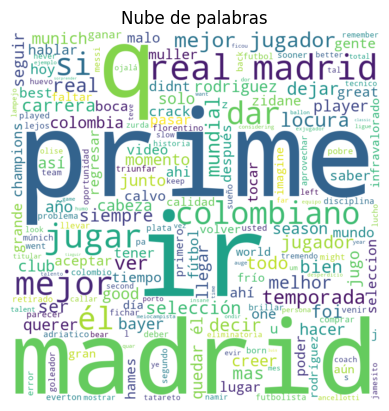

In [82]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

## Obtiene el conteo de palabras y muestra las más repetidas (más relevantes) en un tamaño de fuente mucho mayor

text = " ".join(df['comentario_limpio'])
wordcloud = WordCloud(width=800, height=800, background_color='white').generate(text)
plt.figure()
plt.imshow(wordcloud, interpolation='bilinear')
plt.title(f"Nube de palabras")
plt.axis("off")
plt.show()


## Aplicando análisis de sentimientos

In [83]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Usuario\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [84]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Analizador de sentimientos
sid = SentimentIntensityAnalyzer()

# Definir una funcion para asignar el sentimiento a cada comentario
def get_sentiment(text):
    scores = sid.polarity_scores(text)
    compound_score = scores['compound']
    if compound_score > 0.05:
        return 'Positive'
    elif compound_score < -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Aplicar la funcion de sentimiento a los comentarios
df['sentimiento'] = df['comentario_limpio'].apply(get_sentiment)

In [85]:
df[['text','sentimiento']]

,text,sentimiento
0,Classic. No 10.,Neutral
1,Lo que fue james y tiago juntos en ese bayer ...,Neutral
2,"Se sorprenden con LUIS DIAZ,.......YA SE LES O...",Neutral
3,Cómo no te va a gustar el frío de Munich James...,Neutral
4,初っ端から天才すぎる,Neutral
...,...,...
156,"James es mañoso, calculador, trotoncito. Un pe...",Neutral
157,"Nice video, but not prime James.",Neutral
158,JAJAJAJAJAJAJ SOLOVIVEN DEL RECUERDO ES UN EXJ...,Neutral
159,ídolo total James,Neutral


<Axes: xlabel='sentimiento'>

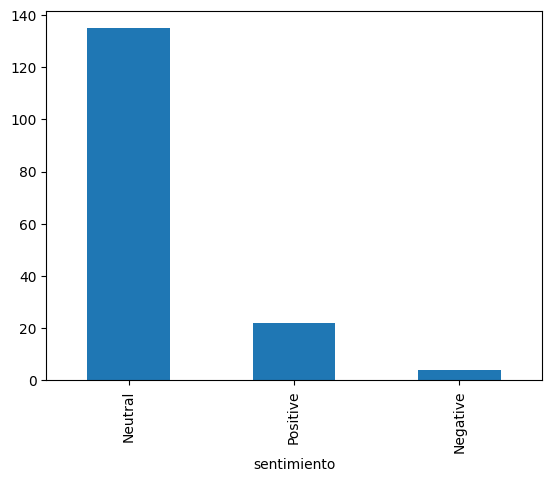

In [86]:
df.value_counts('sentimiento').plot(kind='bar')

## Aplicando vectorización a los datos

Usar un vectorizador para convertir los comentarios de texto a una representacion numerica

In [87]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF vectoriza el texto dando relevancia a las palabras no tan comunes, las cuales proveen mayor cercanía al contexto de la situación
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['comentario_limpio']).toarray()

In [88]:
df_train= pd.DataFrame(X, columns=vectorizer.get_feature_names_out())
df_train

,about,abrir,acabar,accurate,aceptar,across,actively,actuación,adelante,adriatico,...,yes,you,yá,zidane,zidanecomo,zidano,zurda,él,ídolo,óptimo
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.376848,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
157,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
158,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
159,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.734159,0.0


In [89]:
X.shape

(161, 771)

In [90]:
import joblib
vectorizador = joblib.load('vectorizador.pkl')
modelo = joblib.load('modelo_sentimiento.pkl')
X = vectorizador.transform(df['comentario_limpio']).toarray()
predicciones = modelo.predict(X)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [91]:
df = df.merge(pd.DataFrame(predicciones, columns=['prediccion']), left_index=True, right_index=True)
df['sentimiento'] = df['prediccion'].apply(lambda x: 'Positivo' if x > 0.5 else 'Negativo') 
df

,cid,text,time,author,channel,votes,replies,photo,heart,reply,time_parsed,comentario_limpio,sentimiento,prediccion
0,UgzbZC3GyhV-x9tcVf54AaABAg,Classic. No 10.,hace 2 semanas,@WowW-vw9wo,UClHpfUbqBqb5ccrQj97DgMg,191,1,https://yt3.ggpht.com/ytc/AIdro_mmWqNlRovwqpf2...,False,False,1.773277e+09,classic,Positivo,0.900418
1,UgxzDC0YMndSk3gumkd4AaABAg,Lo que fue james y tiago juntos en ese bayer ...,hace 12 días,@diegojimenez-c8m,UCMKuBMUoaZRaNY6wM0ijDUw,28,,https://yt3.ggpht.com/ytc/AIdro_kXlbIj8ZPnDdAy...,False,False,1.773450e+09,tiaguir junto bayer locura,Positivo,0.521461
2,Ugx81Zn9QFM50qXZ72B4AaABAg,"Se sorprenden con LUIS DIAZ,.......YA SE LES O...",hace 11 días,@JuanPabloJiménezRios-j2x,UClXwXqhky1tI02DBw7TAX6A,19,,https://yt3.ggpht.com/ytc/AIdro_l8eo8-U6Hq182H...,False,False,1.773536e+09,sorprender luis diazya olvidar todo actuación ...,Positivo,0.612193
3,Ugy20vZPyQNhoNKxnbx4AaABAg,Cómo no te va a gustar el frío de Munich James...,hace 2 semanas,@gabrielgranados2428,UCRBfosTXjhkofc_KKkHpsrg,314,23,https://yt3.ggpht.com/ytc/AIdro_mM_huKT3rlxAl2...,False,False,1.773277e+09,cómo ir gustar frío munich caremonda carrera a...,Positivo,0.730737
4,Ugx_yQajsHiPRtaNzix4AaABAg,初っ端から天才すぎる,hace 2 semanas,@tk-wv6yq,UCp904pEY40lYlZ9WwN3cBjg,45,,https://yt3.ggpht.com/ytc/AIdro_kH1ycPLoEVEFp2...,False,False,1.773277e+09,,Positivo,0.521461
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,UgxQ5fFNAeQZlIbiQmh4AaABAg,"James es mañoso, calculador, trotoncito. Un pe...",hace 9 días,@joseconradocortescortes612,UCzgN3QS-cBExSSf-R0kp2QQ,0,,https://yt3.ggpht.com/ytc/AIdro_kLRchHPkvooSd3...,False,False,1.773709e+09,mañoso calculador trotoncitir personaje inflad...,Positivo,0.521461
157,Ugzc_XVU8hp39QAJQPV4AaABAg,"Nice video, but not prime James.",hace 2 semanas (editado),@sebastiandresilva,UCMS0AB4fFt0x5w2k6AQxDzg,0,,https://yt3.ggpht.com/49G7Df6c51QgOHGPK0x1r0VT...,False,False,1.773277e+09,nizar video but not prime,Negativo,0.454636
158,UgzZB8BsTmaRXQPbozV4AaABAg,JAJAJAJAJAJAJ SOLOVIVEN DEL RECUERDO ES UN EXJ...,hace 13 días,@johnARENAS-q2e,UCudozEtOblUTf74LUE_6vFA,0,,https://yt3.ggpht.com/ytc/AIdro_ldr9MvPwL_XnqB...,False,False,1.773364e+09,jajajajajajaj solovivir recuerdo exjugador aho...,Positivo,0.722657
159,UgyzbWMZ704ooTAHnOZ4AaABAg,ídolo total James,hace 2 semanas,@jadadelpolaco,UCxKR4KYBUVaJ6Xz3MjJi8XQ,7,,https://yt3.ggpht.com/ytc/AIdro_khSbcYOk-ZJpJd...,False,False,1.773277e+09,ídolo total,Negativo,0.183424


## Segmentación por temáticas internas en el texto con LDA

In [92]:
from sklearn.decomposition import LatentDirichletAllocation

# Determinar un número apropiado de tematicas a analizar
n_topics = 5

# Usar un modelo de LatentDirichletAllocation
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42)
lda.fit(X)

# Obtener la distribución de los temas para cada comentario
topic_distribution = lda.transform(X)

# Asignar el tema dominante a cada comentario
df['tema_dominante'] = topic_distribution.argmax(axis=1)

topic_distribution

array([[0.10002274, 0.10002277, 0.10002292, 0.10002272, 0.59990886],
       [0.2       , 0.2       , 0.2       , 0.2       , 0.2       ],
       [0.10002278, 0.10002281, 0.10002296, 0.59990863, 0.10002281],
       [0.10000249, 0.10000247, 0.10000249, 0.59999005, 0.1000025 ],
       [0.2       , 0.2       , 0.2       , 0.2       , 0.2       ],
       [0.2       , 0.2       , 0.2       , 0.2       , 0.2       ],
       [0.07607862, 0.07607867, 0.69121812, 0.08018626, 0.07643832],
       [0.10002274, 0.10002277, 0.10002292, 0.10002272, 0.59990886],
       [0.2       , 0.2       , 0.2       , 0.2       , 0.2       ],
       [0.08293351, 0.66826574, 0.08293372, 0.08293349, 0.08293354],
       [0.10000277, 0.59961394, 0.10000275, 0.10037781, 0.10000273],
       [0.59999169, 0.10000209, 0.10000208, 0.10000209, 0.10000206],
       [0.2       , 0.2       , 0.2       , 0.2       , 0.2       ],
       [0.2       , 0.2       , 0.2       , 0.2       , 0.2       ],
       [0.2       , 0.2       , 0.

In [93]:
df.head()

,cid,text,time,author,channel,votes,replies,photo,heart,reply,time_parsed,comentario_limpio,sentimiento,prediccion,tema_dominante
0,UgzbZC3GyhV-x9tcVf54AaABAg,Classic. No 10.,hace 2 semanas,@WowW-vw9wo,UClHpfUbqBqb5ccrQj97DgMg,191,1,https://yt3.ggpht.com/ytc/AIdro_mmWqNlRovwqpf2...,False,False,1.773277e+09,classic,Positivo,0.900418,4
1,UgxzDC0YMndSk3gumkd4AaABAg,Lo que fue james y tiago juntos en ese bayer ...,hace 12 días,@diegojimenez-c8m,UCMKuBMUoaZRaNY6wM0ijDUw,28,,https://yt3.ggpht.com/ytc/AIdro_kXlbIj8ZPnDdAy...,False,False,1.773450e+09,tiaguir junto bayer locura,Positivo,0.521461,0
2,Ugx81Zn9QFM50qXZ72B4AaABAg,"Se sorprenden con LUIS DIAZ,.......YA SE LES O...",hace 11 días,@JuanPabloJiménezRios-j2x,UClXwXqhky1tI02DBw7TAX6A,19,,https://yt3.ggpht.com/ytc/AIdro_l8eo8-U6Hq182H...,False,False,1.773536e+09,sorprender luis diazya olvidar todo actuación ...,Positivo,0.612193,3
3,Ugy20vZPyQNhoNKxnbx4AaABAg,Cómo no te va a gustar el frío de Munich James...,hace 2 semanas,@gabrielgranados2428,UCRBfosTXjhkofc_KKkHpsrg,314,23,https://yt3.ggpht.com/ytc/AIdro_mM_huKT3rlxAl2...,False,False,1.773277e+09,cómo ir gustar frío munich caremonda carrera a...,Positivo,0.730737,3
4,Ugx_yQajsHiPRtaNzix4AaABAg,初っ端から天才すぎる,hace 2 semanas,@tk-wv6yq,UCp904pEY40lYlZ9WwN3cBjg,45,,https://yt3.ggpht.com/ytc/AIdro_kH1ycPLoEVEFp2...,False,False,1.773277e+09,,Positivo,0.521461,0


In [97]:
# Indentificar las palabras clave para cada uno de los temas
feature_names = vectorizador.get_feature_names_out()
topic_words = []
for topic_idx, topic in enumerate(lda.components_):
    top_words_indices = topic.argsort()[:-5 - 1:-1]
    top_words = [feature_names[i] for i in top_words_indices]
    print(f"Topic {topic_idx}: {', '.join(top_words)}")
    topic_words.append(', '.join(top_words))

df_topic_words = pd.DataFrame(topic_words, columns=['palabras clave'])
df_topic_words.head()

Topic 0: real, crack, titular, jar, pa
Topic 1: prime, in, video, talent, slow
Topic 2: club, total, ex, great, rodriguez
Topic 3: ir, solo, saber, rodriguez, player
Topic 4: in, better, classic, pre, top


,palabras clave
0,"real, crack, titular, jar, pa"
1,"prime, in, video, talent, slow"
2,"club, total, ex, great, rodriguez"
3,"ir, solo, saber, rodriguez, player"
4,"in, better, classic, pre, top"


## Segmentacion de clientes



In [98]:
customer_segments = df.groupby(['tema_dominante', 'sentimiento']).size().reset_index(name='comment_count')
display(customer_segments)

,tema_dominante,sentimiento,comment_count
0,0,Negativo,4
1,0,Positivo,97
2,1,Negativo,11
3,1,Positivo,6
4,2,Negativo,2
5,2,Positivo,5
6,3,Negativo,4
7,3,Positivo,17
8,4,Negativo,6
9,4,Positivo,9


## Caracterizacion de cada segmento de clientes


In [99]:
df_topic_words

,palabras clave
0,"real, crack, titular, jar, pa"
1,"prime, in, video, talent, slow"
2,"club, total, ex, great, rodriguez"
3,"ir, solo, saber, rodriguez, player"
4,"in, better, classic, pre, top"


In [100]:
segment_0_sentiment = customer_segments[customer_segments['tema_dominante'] == 0]
print("Segmento 0:")
display(segment_0_sentiment.sort_values(by='comment_count', ascending=False))
display(df_topic_words.iloc[0])

segment_1_sentiment = customer_segments[customer_segments['tema_dominante'] == 1]
print("Segmento 1:")
display(segment_1_sentiment.sort_values(by='comment_count', ascending=False))
display(df_topic_words.iloc[1])

segment_2_sentiment = customer_segments[customer_segments['tema_dominante'] == 2]
print("Segmento 2:")
display(segment_2_sentiment.sort_values(by='comment_count', ascending=False))
display(df_topic_words.iloc[2])

segment_3_sentiment = customer_segments[customer_segments['tema_dominante'] == 3]
print("Segmento 3:")
display(segment_3_sentiment.sort_values(by='comment_count', ascending=False))
display(df_topic_words.iloc[3])

segment_4_sentiment = customer_segments[customer_segments['tema_dominante'] == 4]
print("Segmento 4:")
display(segment_4_sentiment.sort_values(by='comment_count', ascending=False))
display(df_topic_words.iloc[4])

Segmento 0:


,tema_dominante,sentimiento,comment_count
1,0,Positivo,97
0,0,Negativo,4


palabras clave    real, crack, titular, jar, pa
Name: 0, dtype: str

Segmento 1:


,tema_dominante,sentimiento,comment_count
2,1,Negativo,11
3,1,Positivo,6


...

,tema_dominante,sentimiento,comment_count
7,3,Positivo,17
6,3,Negativo,4


palabras clave    ir, solo, saber, rodriguez, player
Name: 3, dtype: str

Segmento 4:


,tema_dominante,sentimiento,comment_count
9,4,Positivo,9
8,4,Negativo,6


palabras clave    in, better, classic, pre, top
Name: 4, dtype: str